# Healthcare Accessibility Classification: Identifying Underserved ZIP Codes in Houston

## 1. Introduction
This Exploratory Data Analysis (EDA) serves as the foundation for identifying "healthcare deserts" within the Houston, Texas, metropolitan area. This project simulates a real-world use case for a Healthcare Real Estate Investment Trust (REIT) aiming to optimize facility placement by identifying areas where high demographic demand meets low healthcare supply.

### 1.1 Objective
The primary goal is to build an end-to-end data science pipeline that classifies Houston-area ZIP codes as "underserved" based on the relationship between healthcare facility density and key demographic demand indicators.

### 1.2 Business Problem
**Problem Statement:** Where are high-demand areas (specifically those with an aging population) underserved by current healthcare infrastructure? 

To address this, the project will:
* Quantify healthcare facility density per ZIP code.
* Analyze the relationship between demographic demand and facility supply.
* Provide actionable insights for potential new facility investment.

### 1.3 Research Question
Can demographic indicators—specifically median age, total population, and median household income—accurately predict whether a Houston-area ZIP code is "underserved" (defined as having a facility density below the 25th percentile)?

### 1.4 Hypothesis
Houston ZIP codes with a higher-than-average median age and lower-than-average household income are significantly more likely to be classified as healthcare deserts (underserved) compared to more affluent, younger areas.

---

## 2. Data Overview
The analysis joins two primary public datasets by 5-digit ZIP code:

* **Supply Data:** CMS Provider of Services (POS) File, containing geographic and type data for hospitals, clinics, and other certified facilities.
* **Demand Data:** U.S. Census Bureau ACS 5-Year Estimates for median age, total population, and median household income.

In [116]:
# import standard libraries
import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [117]:
BASE_DIR = os.path.dirname(os.getcwd()) # Gets the root project directory
data_folder = os.path.join(BASE_DIR, "data")

In [118]:
# Load datasets
census_df = pd.read_csv(os.path.join(data_folder, "raw_census_data.csv"))
healthcare_df = pd.read_csv(os.path.join(data_folder, "raw_pos.csv"))
print("Datasets loaded successfully!")
print(f"Census shape: {census_df.shape}")
print(f"POS shape: {healthcare_df.shape}")

C:\Users\willi\AppData\Local\Temp\ipykernel_28168\3362416116.py:3: DtypeWarning: Columns (8,17,18,19,100) have mixed types. Specify dtype option on import or set low_memory=False.
  healthcare_df = pd.read_csv(os.path.join(data_folder, "raw_pos.csv"))


Datasets loaded successfully!
Census shape: (1989, 11)
POS shape: (77283, 182)


In [119]:
print("Census Data Sample:")
print(census_df.head())
print("\nPoint of Service Data Sample:")
print(healthcare_df.head())

Census Data Sample:
   zip_code  median_age  total_population  median_household_income  \
0     75001        33.8           16633.0                  77598.0   
1     75002        38.8           72679.0                 119301.0   
2     75006        36.2           48062.0                  79672.0   
3     75007        40.6           54498.0                 105969.0   
4     75009        37.1           28109.0                 153658.0   

   bachelors_degree  masters_degree  below_poverty  unemployed  \
0            4875.0          1965.0         1404.0       400.0   
1           16165.0          6082.0         3890.0      1732.0   
2            7733.0          2357.0         3777.0      1057.0   
3           12001.0          3981.0         4141.0      1215.0   
4            6690.0          1960.0         1493.0       699.0   

   uninsured_adults  with_disability  no_vehicle_households  
0             516.0          16594.0                  262.0  
1            1000.0          72481.0  

We need to merge in zip code but before we do that we need to group the healthcare_df by zip code and get a facility count

In [120]:
# Force both to strings and pad with zeros to ensure '07701' doesn't become '7701'
census_df['zip_code'] = census_df['zip_code'].astype(str).str.strip().str.zfill(5)
healthcare_df['zip_cd'] = healthcare_df['zip_cd'].astype(str).str.strip().str.zfill(5)

# Group healthcare facilities by ZIP to get a count
healthcare_counts = healthcare_df.groupby('zip_cd').size().reset_index(name='facility_count')

# Double check the sample now
print(f"Sample Census ZIP: '{census_df['zip_code'].iloc[0]}'")
print(f"Sample Healthcare ZIP: '{healthcare_counts['zip_cd'].iloc[0]}'")

Sample Census ZIP: '75001'
Sample Healthcare ZIP: '00601'


In [121]:
# Merge census data with healthcare facility counts on ZIP code
merged_df = pd.merge(
    census_df, 
    healthcare_counts, 
    left_on='zip_code', 
    right_on='zip_cd', 
    how='left'
)

# fill in missing facility counts with 0 (indicating no facilities in that ZIP code)
merged_df['facility_count'] = merged_df['facility_count'].fillna(0)

# Drop the redundant column from the merge
if 'zip_cd' in merged_df.columns:
    merged_df = merged_df.drop(columns=['zip_cd'])

print("Merge Complete!")
print(merged_df.isnull().sum())

Merge Complete!
zip_code                     0
median_age                  82
total_population            56
median_household_income    227
bachelors_degree           170
masters_degree             271
below_poverty              203
unemployed                 364
uninsured_adults           395
with_disability             69
no_vehicle_households      400
facility_count               0
dtype: int64


In Census data, `NaN` values usually occur in ZIP codes with very small populations, industrial areas (like refineries in East Houston), or parks where people don't live.
The first thing we will address in droping the Ghost zip Codes by removing rows where total_population is 0 or where core features (median_age, median_household_income) are missing.

In [122]:
# Drop rows where critical modeling variables are missing
# These ZIPs aren't useful for a demand-supply model
df_clean = merged_df.dropna(subset=['median_age', 'total_population', 'median_household_income']).copy()

For features like `no_vehicle_households` or `unemployed`, where we have ~400 missing values we can fill the NaN with the Median of the rest of Houston. Income and employment data are often skewed; the median is more robust than the mean.

In [123]:
# Fill secondary features with the median
secondary_cols = ['unemployed', 'uninsured_adults', 'no_vehicle_households', 'with_disability']
for col in secondary_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print(df_clean.isnull().sum())

zip_code                     0
median_age                   0
total_population             0
median_household_income      0
bachelors_degree            35
masters_degree             104
below_poverty               53
unemployed                   0
uninsured_adults             0
with_disability              0
no_vehicle_households        0
facility_count               0
dtype: int64


There are still NULL values in `bachelors_degree`, `masters_degree` and`below_poverty`. 
First we will filter the data frame for population over 100, then we will fill the NULL values 
with the median. 

In [124]:
# Only calculate for ZIPs with population > 100
df_clean = df_clean[df_clean['total_population'] > 100].copy()

# Final sweep for education and poverty metrics
final_impute_cols = ['bachelors_degree', 'masters_degree', 'below_poverty']

for col in final_impute_cols:
    # Fill with median to stay 'average'
    df_clean.loc[:, col] = df_clean[col].fillna(df_clean[col].median())

# Verify one last time
print("Final Null Check:")
print(df_clean[final_impute_cols].isnull().sum())


Final Null Check:
bachelors_degree    0
masters_degree      0
below_poverty       0
dtype: int64


We must also create a facility_density variable. 

In [125]:
# Calculate Density: Facilities per 1,000 residents
df_clean['facility_density'] = (df_clean['facility_count'] / df_clean['total_population']) * 1000

# Cap extreme outliers
q_99 = df_clean['facility_density'].quantile(0.99)
df_clean['facility_density'] = df_clean['facility_density'].clip(upper=q_99)

***
## 3. Feature Analysis
### 3.1 Multivariate Analysis: Feature Correlation
Before proceeding to Logistic Regression, we utilize a correlation matrix to examine the linear relationships between our features and our target variable (`facility_density`). 

**Key Objectives:**
* **Identify Multicollinearity:** Logistic regression assumes that independent variables are not highly correlated with each other. If two features (e.g., `median_household_income` and `bachelors_degree`) are too similar, they can "confuse" the model's coefficients.
* **Hypothesis Validation:** We look for initial signs of the expected negative correlation between demographic barriers (like `unemployed` or `no_vehicle_households`) and healthcare supply.

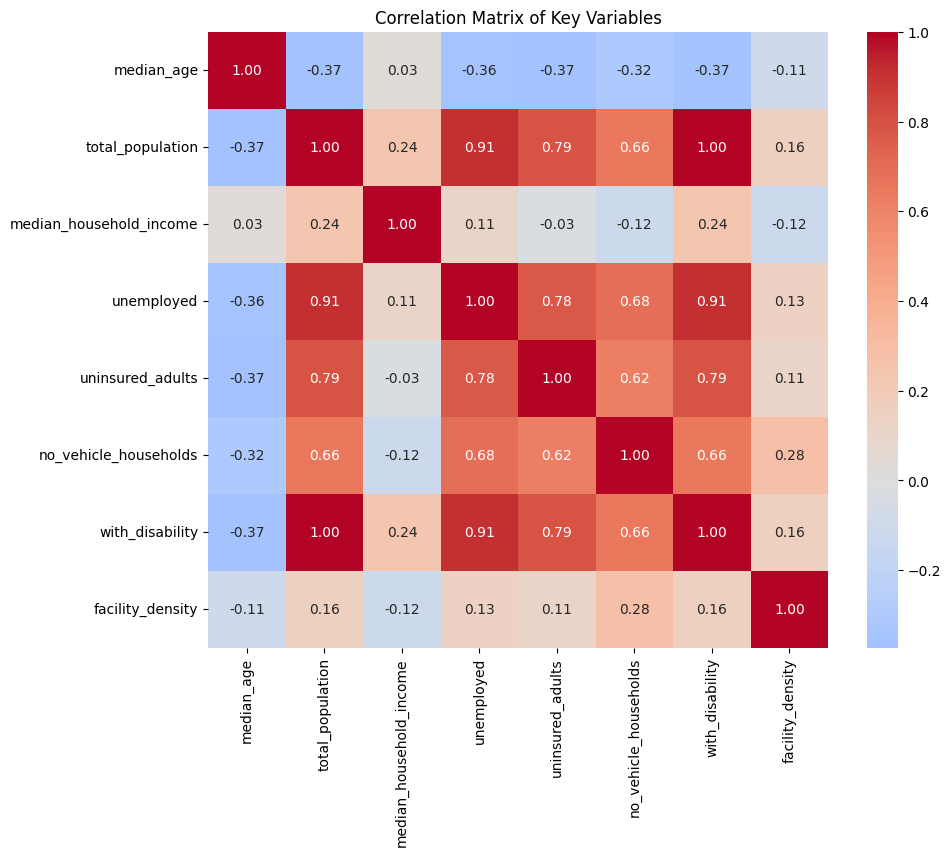

In [126]:
# Select core features for the correlation matrix
cols_to_corr = [
    'median_age', 'total_population', 'median_household_income', 
    'unemployed', 'uninsured_adults', 'no_vehicle_households', 
    'with_disability', 'facility_density'
]

correlation_matrix = df_clean[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation Matrix of Key Variables")
plt.show()

### Interpretation of Correlation Matrix
Upon reviewing the heatmap, we evaluate the following:
* **Target Relationship:** How strongly do `median_age` and `median_household_income` correlate with `facility_density`? A correlation coefficient near 0 suggests a non-linear relationship, which further justifies the move to a classification approach.
* **Demand Indicators:** High positive correlations between variables like `uninsured_adults` and `unemployed` are expected; however, if any correlation exceeds **0.80**, we may consider dropping one of the features during the modeling phase to prevent overfitting.

***


### 3.2 Distribution of Healthcare Facility Density
We analyze the distribution of our target variable to identify outliers. In urban centers like Houston, healthcare infrastructure is often hyper-concentrated in specific districts (e.g., the Texas Medical Center), which can skew density metrics.

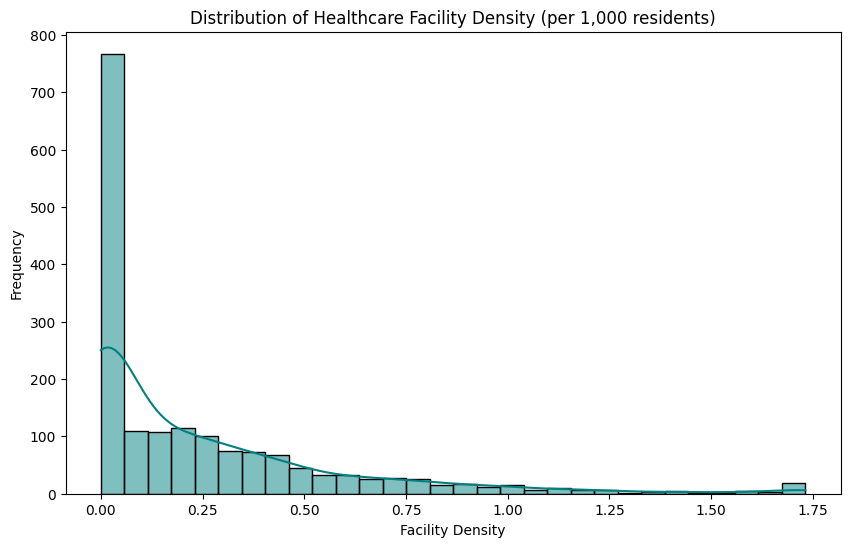

In [127]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['facility_density'], bins=30, kde=True, color='teal')
plt.title('Distribution of Healthcare Facility Density (per 1,000 residents)')
plt.xlabel('Facility Density')
plt.ylabel('Frequency')
plt.show()

***
### 3.3 Relationship: Demand Indicators vs. Supply Density
Following our hypothesis, we expect to see a negative correlation between areas with high median age and healthcare density, as well as a positive correlation between household income and facility access.

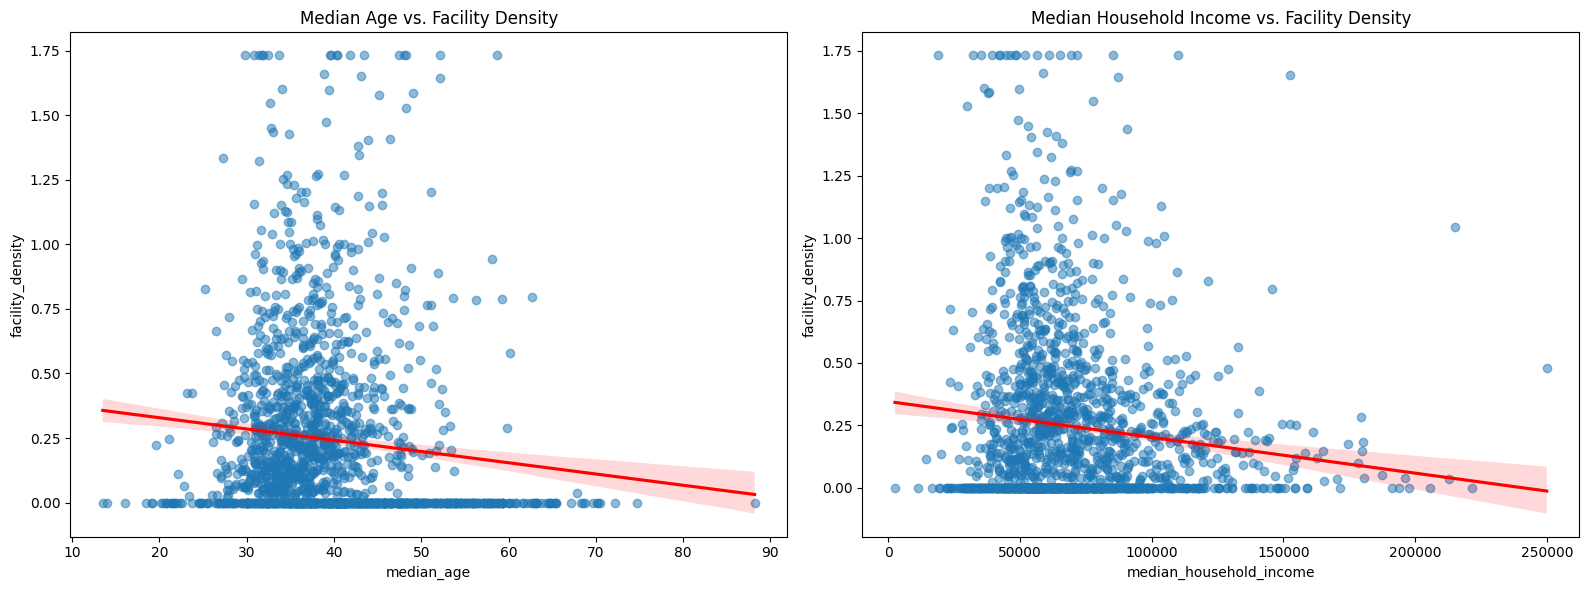

In [128]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Median Age vs Density
sns.regplot(x='median_age', y='facility_density', data=df_clean, ax=ax1, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax1.set_title('Median Age vs. Facility Density')

# Median Income vs Density
sns.regplot(x='median_household_income', y='facility_density', data=df_clean, ax=ax2, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax2.set_title('Median Household Income vs. Facility Density')

plt.tight_layout()
plt.show()

### 3.3.1 Critical Reflection on Correlation Results
The observed negative correlation between **Median Household Income** and **Facility Density** is a notable pivot from our initial hypothesis. 

**Preliminary Inference:** High-density healthcare clusters in Houston (like the Texas Medical Center or downtown cores) often exist in ZIP codes with lower median household incomes or higher industrial presence. Conversely, high-income suburban ZIP codes may show lower density due to large residential populations with fewer localized "big box" medical facilities.

This suggests that **Access** (density) and **Affluence** (income) are not perfectly aligned in Houston, necessitating a more robust **Logistic Regression** model to classify these areas based on a combination of factors rather than a single demographic indicator.